## Exploratory Data Analysis

Sentiment/rating distributions, class imbalance analysis, label provenance breakdown (human-annotated pilot vs model pseudo-labels), review length by sentiment, free-text vs auto-tag share, and temporal sentiment trends.

Loaded dataset: ../data/final_pseudo_labeled_dataset.csv (22,448 rows)
Columns: ['review_id', 'review', 'rating', 'sentiment', 'label_source', 'prediction_confidence', 'needs_human_review', 'split_role', 'is_autotag', 'store_name', 'store_address', 'review_time', 'days_ago', 'review_clean', 'rating_num', 'reviewer_id']

CLASS IMBALANCE & LABEL PROVENANCE

Label Source Breakdown:
label_source
model_pseudo_label    21448
human_annotated        1000
Name: count, dtype: int64

Sentiment Class Distribution (Target Imbalance):
  Negative  : 10,626 (47.34%)
  Positive  :  8,292 (36.94%)
  Neutral   :  3,530 (15.73%)

Majority / Minority Class Ratio: 3.01
-> Dataset is imbalanced. Recommendation: Use stratified splits, balanced class weights (w_j = N / (K * n_j)), and Macro-F1 metric.


C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_12084\2828461265.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", order=order, palette=colors, ax=axes[0])
C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_12084\2828461265.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating_num", palette="Blues_d", ax=axes[1])


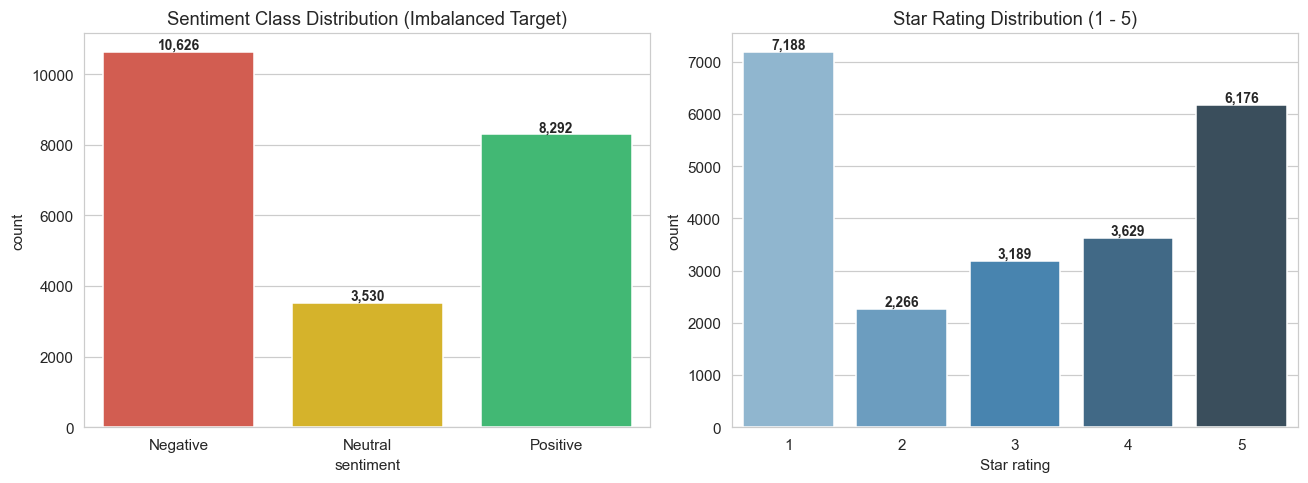

C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_12084\2828461265.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["review_len"] < 600], x="sentiment", y="review_len",


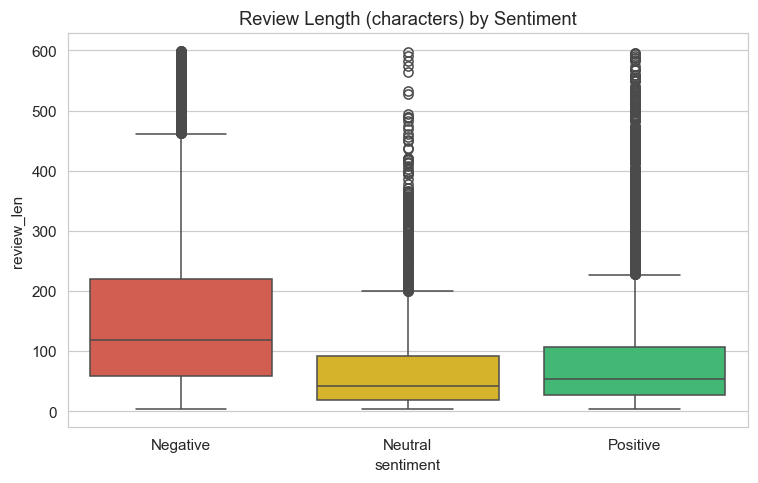

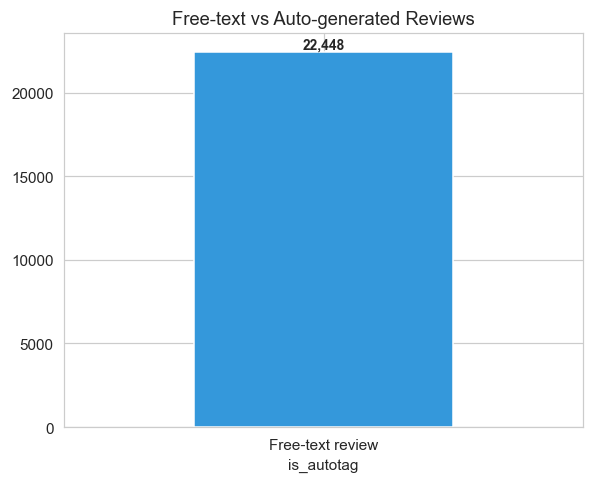

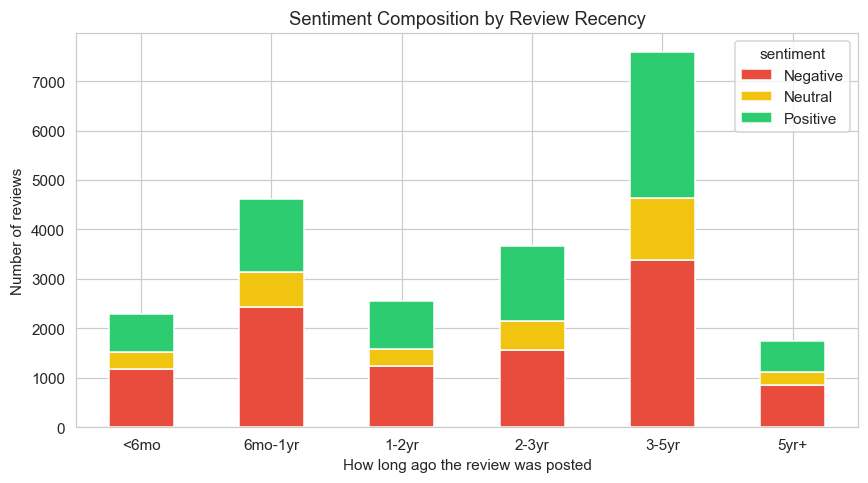

,review_len,word_count
count,22448.000000,22448.000000
mean,136.180061,25.522006
std,177.819141,33.901150
min,3.000000,1.000000
25%,35.000000,6.000000
50%,77.000000,14.000000
75%,167.000000,31.000000
max,3114.000000,589.000000


In [1]:
%matplotlib inline
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Load final pseudo-labeled dataset (with fallback)
DATA_PATH = "../data/final_pseudo_labeled_dataset.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data/cleaned_reviews.csv"

df = pd.read_csv(DATA_PATH)

# Standardize column aliases across schemas
if "review" in df.columns and "review_clean" not in df.columns:
    df["review_clean"] = df["review"]
if "rating" in df.columns and "rating_num" not in df.columns:
    df["rating_num"] = df["rating"]
if "review_id" in df.columns and "reviewer_id" not in df.columns:
    df["reviewer_id"] = df["review_id"]
if "is_autotag" not in df.columns:
    df["is_autotag"] = False

FIG = "../Figures" if os.path.exists("../Figures") else "Figures"
os.makedirs(FIG, exist_ok=True)

print(f"Loaded dataset: {DATA_PATH} ({len(df):,} rows)")
print(f"Columns: {df.columns.tolist()}")

# ---- Class Imbalance Assessment ----
print("\n" + "=" * 60)
print("CLASS IMBALANCE & LABEL PROVENANCE")
print("=" * 60)

if "label_source" in df.columns:
    print("\nLabel Source Breakdown:")
    print(df["label_source"].value_counts())

print("\nSentiment Class Distribution (Target Imbalance):")
sent_counts = df["sentiment"].value_counts()
for s_cls, cnt in sent_counts.items():
    pct = (cnt / len(df)) * 100
    print(f"  {s_cls:10s}: {cnt:6,d} ({pct:.2f}%)")

majority_cnt = sent_counts.max()
minority_cnt = sent_counts.min()
ratio = majority_cnt / minority_cnt if minority_cnt > 0 else float("inf")
print(f"\nMajority / Minority Class Ratio: {ratio:.2f}")
if ratio >= 1.5:
    print("-> Dataset is imbalanced. Recommendation: Use stratified splits, balanced class weights (w_j = N / (K * n_j)), and Macro-F1 metric.")

# ---- 1. Sentiment / Rating Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["Negative", "Neutral", "Positive"]
colors = ["#e74c3c", "#f1c40f", "#2ecc71"]

sns.countplot(data=df, x="sentiment", order=order, palette=colors, ax=axes[0])
axes[0].set_title("Sentiment Class Distribution (Imbalanced Target)")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

sns.countplot(data=df, x="rating_num", palette="Blues_d", ax=axes[1])
axes[1].set_title("Star Rating Distribution (1 - 5)")
axes[1].set_xlabel("Star rating")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG}/01_sentiment_rating_dist.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- 2. Review Length by Sentiment ----
df["review_len"] = df["review_clean"].astype(str).str.len()
df["word_count"] = df["review_clean"].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df[df["review_len"] < 600], x="sentiment", y="review_len",
            order=order, palette=colors, ax=ax)
ax.set_title("Review Length (characters) by Sentiment")
plt.tight_layout()
plt.savefig(f"{FIG}/02_length_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- 3. Auto-tag (no free text) share ----
fig, ax = plt.subplots(figsize=(5.5, 4.5))
df["is_autotag"].map({True: "Auto-tag\n(no free text)", False: "Free-text review"}).value_counts().plot(
    kind="bar", color=["#3498db", "#95a5a6"], ax=ax)
ax.set_title("Free-text vs Auto-generated Reviews")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG}/03_autotag_share.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- 4. Reviews over time ----
df_time = df.dropna(subset=["days_ago"]).copy()
df_time["years_ago_bin"] = pd.cut(df_time["days_ago"] / 365,
                                   bins=[0, 0.5, 1, 2, 3, 5, 100],
                                   labels=["<6mo", "6mo-1yr", "1-2yr", "2-3yr", "3-5yr", "5yr+"])
fig, ax = plt.subplots(figsize=(8, 4.5))
ct = pd.crosstab(df_time["years_ago_bin"], df_time["sentiment"]).reindex(columns=order, fill_value=0)
ct.plot(kind="bar", stacked=True, color=colors, ax=ax)
ax.set_title("Sentiment Composition by Review Recency")
ax.set_xlabel("How long ago the review was posted")
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/04_sentiment_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

display(df[["review_len", "word_count"]].describe())
